In [38]:
import json
import os
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from matplotlib.ticker import MaxNLocator

### Paths to the data

In [39]:
dataset_path = "../../datasets/Sen1Floods11/v1.1"
splits_path = dataset_path + "/splits"


split_handlabeled = splits_path + "/flood_handlabeled"
split_permanent = splits_path + "/perm_water"

test_labeled_general = split_handlabeled + "/flood_test_data.csv"
test_labeled_bolivia = split_handlabeled + "/flood_bolivia_data.csv"
test_permanent = split_permanent + "/permanent_water_test_data.csv"

print(os.path.exists(test_labeled_general))
print(os.path.exists(test_labeled_bolivia))
print(os.path.exists(test_permanent))

True
True
True


### Paths to the checkpoints

In [40]:
original_checkpoints_path = dataset_path + "/checkpoints"

original_s2weak_cp = original_checkpoints_path + "/5e4_flood_0_89_0.5418742895126343.cp"
original_handlabeled_cp = original_checkpoints_path + "/5e4_handlabeled_0_8_0.43163052201271057.cp"
original_perm_cp = original_checkpoints_path + "/5e4_permanent_0_180_0.8432363867759705.cp"
original_s1weak_cp = original_checkpoints_path + "/5e4_s1weak_2_3_0.45159465074539185.cp"

In [41]:
# Read our selected models directly from the curated checkpoint folder.
my_checkpoints_path = Path("runs/best_checkpoints")

my_s2weak_cp = my_checkpoints_path / "Sen1Floods11_s2_weak_epoch078_valIoU0.619410.cp"
my_handlabeled_cp = my_checkpoints_path / "Sen1Floods11_hand_labeled_epoch051_valIoU0.539782.cp"
my_perm_cp = my_checkpoints_path / "Sen1Floods11_permanent_water_epoch157_valIoU0.854816.cp"
my_s1weak_cp = my_checkpoints_path / "Sen1Floods11_s1_weak_epoch001_valIoU0.438605.cp"


In [42]:
print(os.path.exists(original_s2weak_cp))
print(os.path.exists(original_handlabeled_cp))
print(os.path.exists(original_perm_cp))
print(os.path.exists(original_s1weak_cp))
print(os.path.exists(my_s2weak_cp))
print(os.path.exists(my_handlabeled_cp))
print(os.path.exists(my_perm_cp))
print(os.path.exists(my_s1weak_cp))

True
True
True
True
True
True
True
True


In [43]:
# Load the saved state dictionaries on CPU without allocating GPU memory.
# These are model weights; no training, inference or checkpoint rewriting occurs here.
my_checkpoint_paths = {
    "hand_labeled": my_handlabeled_cp,
    "s1_weak": my_s1weak_cp,
    "s2_weak": my_s2weak_cp,
    "permanent_water": my_perm_cp,
}
my_checkpoints = {}
for variant, checkpoint_path in my_checkpoint_paths.items():
    if not checkpoint_path.is_file():
        raise FileNotFoundError(f"Missing selected checkpoint: {checkpoint_path}")
    my_checkpoints[variant] = torch.load(
        checkpoint_path, map_location="cpu", weights_only=True,
    )
    print(f"Loaded {variant}: {checkpoint_path.name}")


Loaded hand_labeled: Sen1Floods11_hand_labeled_epoch051_valIoU0.539782.cp
Loaded s1_weak: Sen1Floods11_s1_weak_epoch001_valIoU0.438605.cp
Loaded s2_weak: Sen1Floods11_s2_weak_epoch078_valIoU0.619410.cp
Loaded permanent_water: Sen1Floods11_permanent_water_epoch157_valIoU0.854816.cp


In [44]:
my_results_path = "runs/results"

my_handlabeled_results = my_results_path + "/hand_labeled/common_test_results.json"
my_handlabeled_history = my_results_path + "/hand_labeled/training_history.json"

my_s1weak_results = my_results_path + "/s1_weak/common_test_results.json"
my_s1weak_history = my_results_path + "/s1_weak/training_history.json"

my_s2weak_results = my_results_path + "/s2_weak/common_test_results.json"
my_s2weak_history = my_results_path + "/s2_weak/training_history.json"

my_perm_results = my_results_path + "/permanent_water/common_test_results.json"
my_perm_history = my_results_path + "/permanent_water/training_history.json"

for result_path in (
    my_handlabeled_results, my_handlabeled_history,
    my_s1weak_results, my_s1weak_history,
    my_s2weak_results, my_s2weak_history,
    my_perm_results, my_perm_history,
):
    print(f"{result_path}: exists={os.path.exists(result_path)}")


runs/results/hand_labeled/common_test_results.json: exists=True
runs/results/hand_labeled/training_history.json: exists=True
runs/results/s1_weak/common_test_results.json: exists=True
runs/results/s1_weak/training_history.json: exists=True
runs/results/s2_weak/common_test_results.json: exists=True
runs/results/s2_weak/training_history.json: exists=True
runs/results/permanent_water/common_test_results.json: exists=True
runs/results/permanent_water/training_history.json: exists=True


### Some Curves

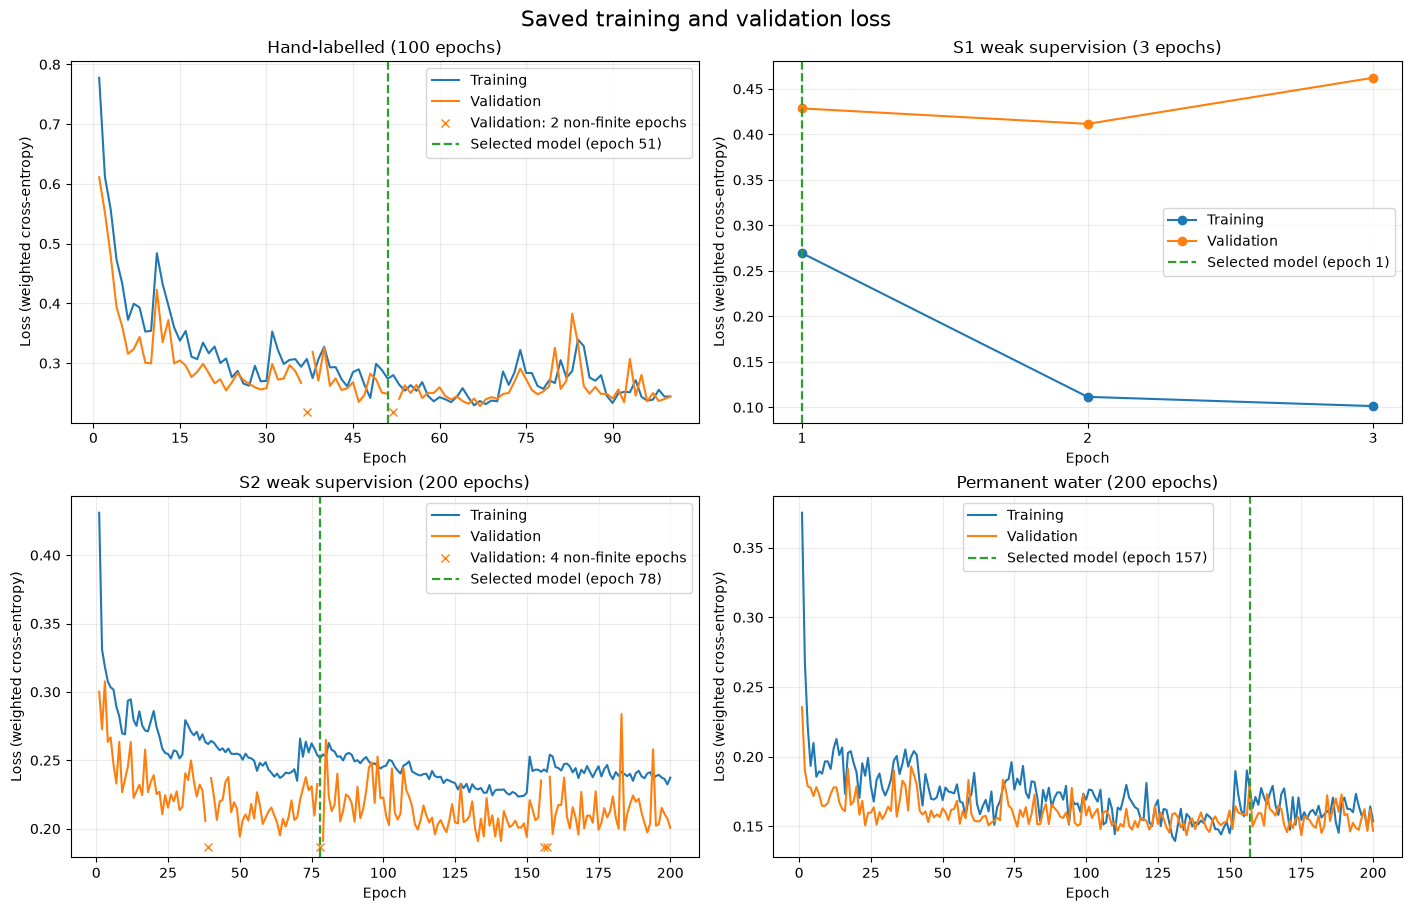

In [45]:
# Use the saved histories defined above; no training or evaluation is rerun.
history_paths = {
    "Hand-labelled": my_handlabeled_history,
    "S1 weak supervision": my_s1weak_history,
    "S2 weak supervision": my_s2weak_history,
    "Permanent water": my_perm_history,
}

# Use the checkpoint chosen for evaluation, rather than the minimum plotted loss.
# The training run selected checkpoints using validation IoU.
checkpoint_paths = {
    "Hand-labelled": my_handlabeled_cp,
    "S1 weak supervision": my_s1weak_cp,
    "S2 weak supervision": my_s2weak_cp,
    "Permanent water": my_perm_cp,
}

# Plot the recorded loss at each epoch without smoothing or rescaling it.
fig, axes = plt.subplots(2, 2, figsize=(14, 9), constrained_layout=True)
for ax, (name, history_path) in zip(axes.flat, history_paths.items()):
    history = json.loads(Path(history_path).read_text(encoding="utf-8"))
    history = sorted(history, key=lambda row: row["epoch"])
    epochs = np.array([row["epoch"] for row in history])

    for prefix, label, color in (
        ("training", "Training", "tab:blue"),
        ("validation", "Validation", "tab:orange"),
    ):
        losses = np.array([row[f"{prefix}_loss"] for row in history], dtype=float)
        missing = ~np.isfinite(losses)
        # Leave NaN/Inf as gaps, rather than interpolating or replacing them with zero.
        losses[missing] = np.nan
        ax.plot(epochs, losses, label=label, color=color,
                marker="o" if len(epochs) <= 10 else None, linewidth=1.5)
        if missing.any():
            # Marks use axes height, not loss values; they identify the missing epochs.
            ax.plot(epochs[missing], np.full(missing.sum(), 0.03),
                    linestyle="none", marker="x", color=color,
                    transform=ax.get_xaxis_transform(),
                    label=f"{label}: {missing.sum()} non-finite epochs")

    # Checkpoint filenames store the same one-based epochs as the saved history.
    match = re.search(r"_epoch(\d+)_", Path(checkpoint_paths[name]).name)
    if match is None:
        raise ValueError(f"Cannot read selected epoch from {checkpoint_paths[name]}")
    selected_epoch = int(match.group(1))
    if selected_epoch not in epochs:
        raise ValueError(f"Selected epoch {selected_epoch} is absent from {history_path}")
    ax.axvline(selected_epoch, color="tab:green", linestyle="--", linewidth=1.6,
               label=f"Selected model (epoch {selected_epoch})")

    # Separate axes accommodate different run lengths and loss ranges.
    ax.set_title(f"{name} ({len(history)} epochs)")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss (weighted cross-entropy)")
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.grid(alpha=0.25)
    ax.legend()

fig.suptitle("Saved training and validation loss", fontsize=16)
plt.show()


Hand-labelled: OK - selected epoch 51, validation IoU 0.539782; maximum 0.539782 at epoch(s) [51]
S1 weak supervision: OK - selected epoch 1, validation IoU 0.438605; maximum 0.438605 at epoch(s) [1]
S2 weak supervision: OK - selected epoch 78, validation IoU 0.619410; maximum 0.619410 at epoch(s) [78]
Permanent water: OK - selected epoch 157, validation IoU 0.854816; maximum 0.854816 at epoch(s) [157]


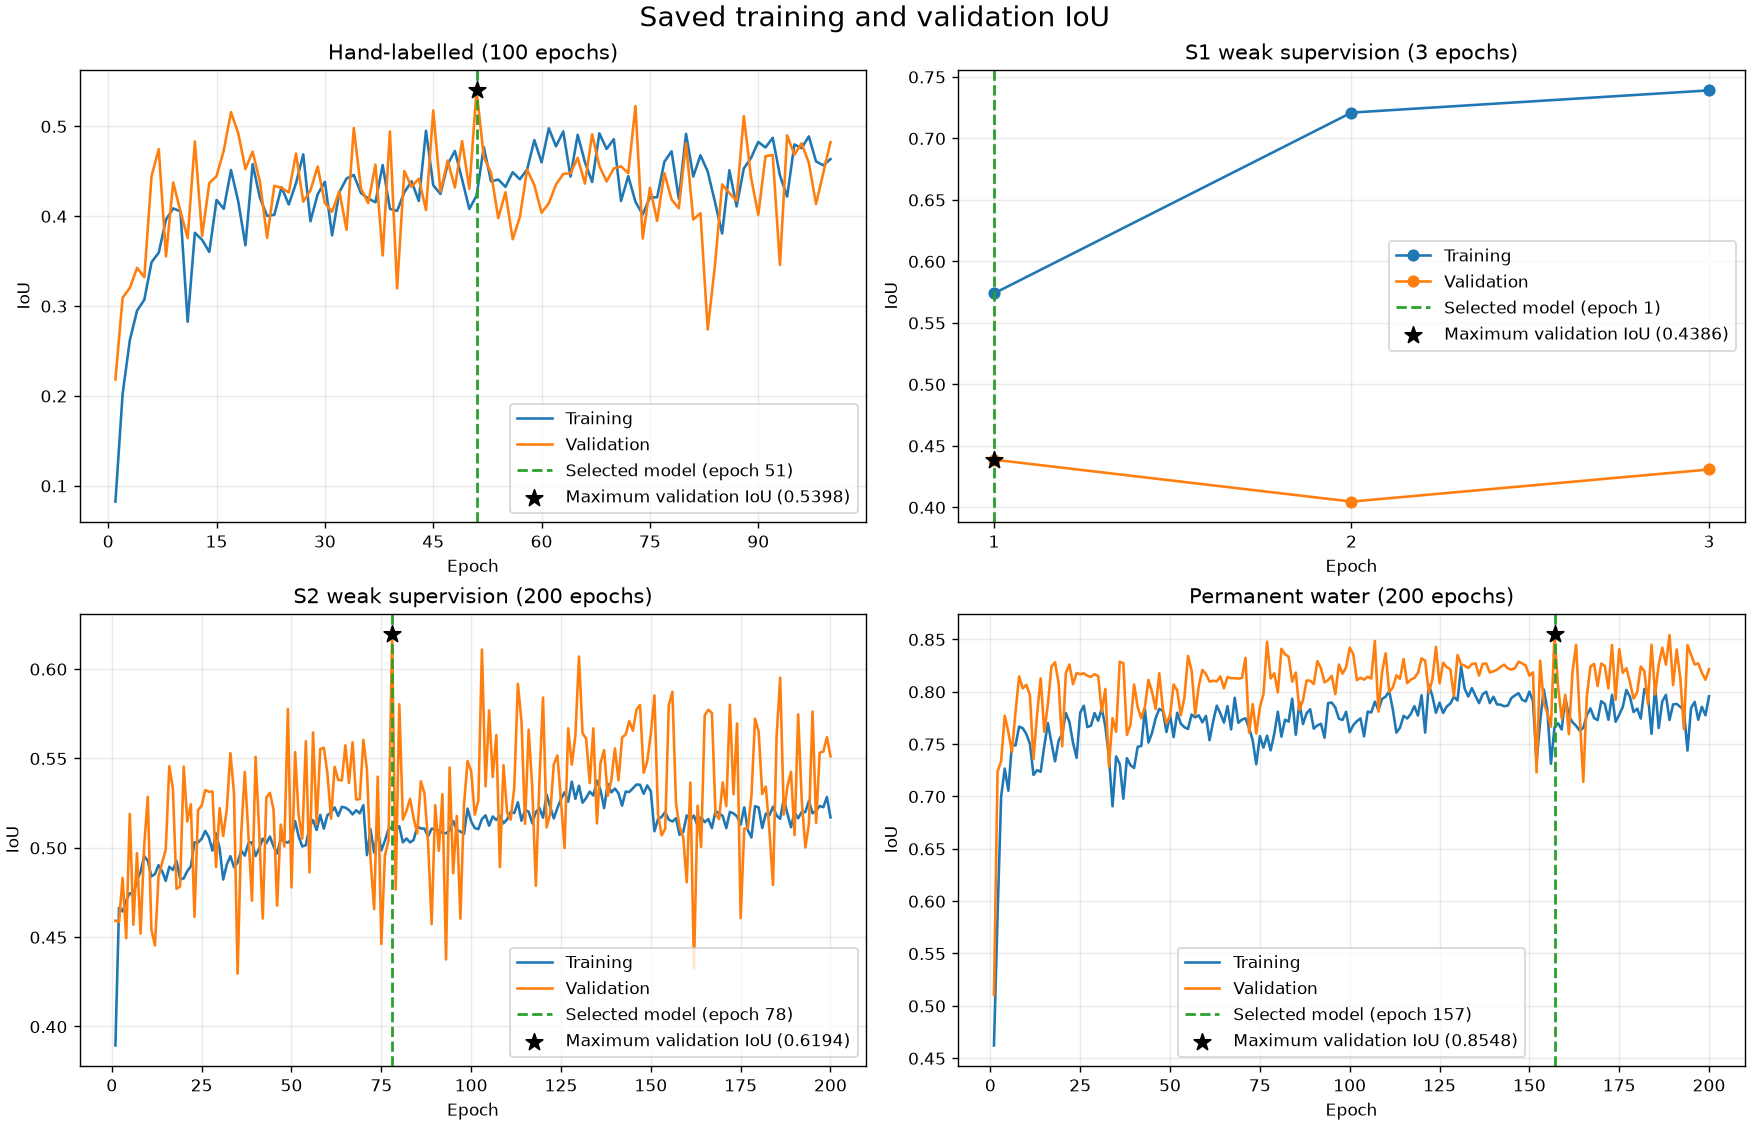

In [9]:
# Use the saved histories defined above; no training or evaluation is rerun.
history_paths = {
    "Hand-labelled": my_handlabeled_history,
    "S1 weak supervision": my_s1weak_history,
    "S2 weak supervision": my_s2weak_history,
    "Permanent water": my_perm_history,
}

# Read the selected epoch from the checkpoint filename independently of the history.
# The training run selected checkpoints using validation IoU.
checkpoint_paths = {
    "Hand-labelled": my_handlabeled_cp,
    "S1 weak supervision": my_s1weak_cp,
    "S2 weak supervision": my_s2weak_cp,
    "Permanent water": my_perm_cp,
}

# Plot recorded IoU without smoothing; leave non-finite values as gaps.
fig, axes = plt.subplots(2, 2, figsize=(14, 9), constrained_layout=True)
for ax, (name, history_path) in zip(axes.flat, history_paths.items()):
    history = json.loads(Path(history_path).read_text(encoding="utf-8"))
    history = sorted(history, key=lambda row: row["epoch"])
    epochs = np.array([row["epoch"] for row in history])

    for prefix, label, color in (
        ("training", "Training", "tab:blue"),
        ("validation", "Validation", "tab:orange"),
    ):
        ious = np.array([row[f"{prefix}_iou"] for row in history], dtype=float)
        missing = ~np.isfinite(ious)
        # Leave NaN/Inf as gaps, rather than interpolating or replacing them with zero.
        ious[missing] = np.nan
        ax.plot(epochs, ious, label=label, color=color,
                marker="o" if len(epochs) <= 10 else None, linewidth=1.5)
        if missing.any():
            # Marks use axes height, not IoU values; they identify the missing epochs.
            ax.plot(epochs[missing], np.full(missing.sum(), 0.03),
                    linestyle="none", marker="x", color=color,
                    transform=ax.get_xaxis_transform(),
                    label=f"{label}: {missing.sum()} non-finite epochs")

    # Checkpoint filenames store the same one-based epochs as the saved history.
    match = re.search(r"_epoch(\d+)_", Path(checkpoint_paths[name]).name)
    if match is None:
        raise ValueError(f"Cannot read selected epoch from {checkpoint_paths[name]}")
    selected_epoch = int(match.group(1))
    if selected_epoch not in epochs:
        raise ValueError(f"Selected epoch {selected_epoch} is absent from {history_path}")
    ax.axvline(selected_epoch, color="tab:green", linestyle="--", linewidth=1.6,
               label=f"Selected model (epoch {selected_epoch})")

    # Independently compare the selected epoch with all finite validation scores.
    validation_iou = np.array([row["validation_iou"] for row in history], dtype=float)
    finite = np.isfinite(validation_iou)
    if not finite.any():
        raise ValueError(f"No finite validation IoU in {history_path}")
    maximum_iou = validation_iou[finite].max()
    maximum_epochs = epochs[finite & (validation_iou == maximum_iou)]
    selected_iou = validation_iou[np.flatnonzero(epochs == selected_epoch)[0]]
    matches_maximum = bool(np.isfinite(selected_iou) and selected_iou == maximum_iou)
    # Mark the actual maximum separately so a mismatched checkpoint remains visible.
    ax.scatter(maximum_epochs, np.full(len(maximum_epochs), maximum_iou),
               color="black", marker="*", s=100, zorder=5,
               label=f"Maximum validation IoU ({maximum_iou:.4f})")
    verification = "OK" if matches_maximum else "MISMATCH"
    print(f"{name}: {verification} - selected epoch {selected_epoch}, "
          f"validation IoU {selected_iou:.6f}; maximum {maximum_iou:.6f} "
          f"at epoch(s) {maximum_epochs.tolist()}")

    # Separate axes accommodate different run lengths and IoU ranges.
    ax.set_title(f"{name} ({len(history)} epochs)")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("IoU")
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.grid(alpha=0.25)
    ax.legend()

fig.suptitle("Saved training and validation IoU", fontsize=16)
plt.show()
